In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
SEED = 42
print('✅ Imports done')

✅ Imports done


In [2]:
train_raw = pd.read_csv('../data/raw/train.csv')
test_raw  = pd.read_csv('../data/raw/test.csv')

# Keep PassengerId for submission
test_ids = test_raw['PassengerId'].copy()

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
train_raw.head()

Train: (8693, 14)  |  Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
# Missing values overview
miss = pd.DataFrame({
    'train_null': train_raw.isnull().sum(),
    'train_pct':  (train_raw.isnull().mean() * 100).round(1),
    'test_null':  test_raw.isnull().sum(),
    'test_pct':   (test_raw.isnull().mean() * 100).round(1),
})
miss[miss.train_null + miss.test_null > 0]

,train_null,train_pct,test_null,test_pct
Age,179,2.1,91.0,2.1
Cabin,199,2.3,100.0,2.3
CryoSleep,217,2.5,93.0,2.2
Destination,182,2.1,92.0,2.2
FoodCourt,183,2.1,106.0,2.5
HomePlanet,201,2.3,87.0,2.0
Name,200,2.3,94.0,2.2
RoomService,181,2.1,82.0,1.9
ShoppingMall,208,2.4,98.0,2.3
Spa,183,2.1,101.0,2.4


In [4]:
# Tag rows and combine
train_raw['_is_train'] = 1
test_raw['_is_train']  = 0
df = pd.concat([train_raw, test_raw], ignore_index=True)
print('Combined shape:', df.shape)

Combined shape: (12970, 15)


In [5]:
# --- Cabin → Deck / Num / Side ---
cabin_split = df['Cabin'].str.split('/', expand=True)
df['CabinDeck'] = cabin_split[0]
df['CabinNum']  = pd.to_numeric(cabin_split[1], errors='coerce')
df['CabinSide'] = cabin_split[2]

print(df[['Cabin','CabinDeck','CabinNum','CabinSide']].head())

   Cabin CabinDeck  CabinNum CabinSide
0  B/0/P         B       0.0         P
1  F/0/S         F       0.0         S
2  A/0/S         A       0.0         S
3  A/0/S         A       0.0         S
4  F/1/S         F       1.0         S


In [6]:
# --- PassengerId → GroupId / MemberNum ---
df['GroupId']   = df['PassengerId'].str.split('_').str[0].astype(int)
df['MemberNum'] = df['PassengerId'].str.split('_').str[1].astype(int)

# GroupSize
group_sizes = df.groupby('GroupId')['PassengerId'].count().rename('GroupSize')
df = df.merge(group_sizes, on='GroupId', how='left')
df['IsSolo'] = (df['GroupSize'] == 1).astype(int)

print(df[['PassengerId','GroupId','GroupSize','IsSolo']].head(8))

  PassengerId  GroupId  GroupSize  IsSolo
0     0001_01        1          1       1
1     0002_01        2          1       1
2     0003_01        3          2       0
3     0003_02        3          2       0
4     0004_01        4          1       1
5     0005_01        5          1       1
6     0006_01        6          2       0
7     0006_02        6          2       0


In [7]:
# --- Name → LastName ---
df['LastName'] = df['Name'].str.split().str[-1]

# FamilySize = count of same LastName within same GroupId
family = df.groupby(['GroupId','LastName'])['PassengerId'].count().rename('FamilySize')
df = df.merge(family, on=['GroupId','LastName'], how='left')

In [8]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Rule 1: CryoSleep=True → spending = 0
cryo_true = df['CryoSleep'] == True
for col in spend_cols:
    df.loc[cryo_true, col] = df.loc[cryo_true, col].fillna(0.0)

# Fill remaining spending NaNs with 0 (zero-inflated distribution)
for col in spend_cols:
    df[col] = df[col].fillna(0.0)

# Rule 2: Infer CryoSleep from spending
cryo_nan = df['CryoSleep'].isna()
all_zero = (df[spend_cols] == 0).all(axis=1)
df.loc[cryo_nan & all_zero,  'CryoSleep'] = True
df.loc[cryo_nan & ~all_zero, 'CryoSleep'] = False

In [9]:
# Age: median (stratified by HomePlanet where possible)
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# VIP: overwhelmingly False → fill with False
# Rule: children < 13 can't be VIP
df.loc[(df['Age'] < 13) & (df['VIP'].isna()), 'VIP'] = False
df['VIP'] = df['VIP'].fillna(False)

# Categoricals: mode from train portion
train_mask = df['_is_train'] == 1
for col in ['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide']:
    mode_val = df.loc[train_mask, col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# CabinNum: median
df['CabinNum'] = df['CabinNum'].fillna(df['CabinNum'].median())

# FamilySize: fill with 1
df['FamilySize'] = df['FamilySize'].fillna(1)

print('Remaining nulls (excluding Name, PassengerId, Cabin):')
remaining = df.drop(columns=['Name','PassengerId','Cabin','Transported','_is_train']).isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None ✅')

Remaining nulls (excluding Name, PassengerId, Cabin):
LastName    294
dtype: int64


In [10]:
# Total spending (on raw values, BEFORE log transform)
df['TotalSpend'] = df[spend_cols].sum(axis=1)
df['HasSpent']   = (df['TotalSpend'] > 0).astype(int)

# Spend ratios (what fraction went to each amenity)
for col in spend_cols:
    df[f'{col}_ratio'] = df[col] / (df['TotalSpend'] + 1)  # +1 avoids div/0

# Age features
bins   = [0, 5, 12, 17, 25, 40, 60, 200]
labels = ['Infant','Child','Teen','YoungAdult','Adult','MidAge','Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
df['IsChild']  = (df['Age'] <= 12).astype(int)

# Cabin region: split CabinNum into quantile-based regions
df['CabinRegion'] = pd.qcut(df['CabinNum'], q=4, labels=['Front','Mid1','Mid2','Rear'], duplicates='drop')

# Interaction features
df['CryoSolo'] = ((df['CryoSleep'] == True) & (df['IsSolo'] == 1)).astype(int)

print('Feature count:', df.shape[1])
df.head(3)

Feature count: 35


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,_is_train,CabinDeck,CabinNum,CabinSide,GroupId,MemberNum,GroupSize,IsSolo,LastName,FamilySize,TotalSpend,HasSpent,RoomService_ratio,FoodCourt_ratio,ShoppingMall_ratio,Spa_ratio,VRDeck_ratio,AgeGroup,IsChild,CabinRegion,CryoSolo
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1,B,0.0,P,1,1,1,1,Ofracculy,1.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,Adult,0,Front,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,1,F,0.0,S,2,1,1,1,Vines,1.0,736.0,1,0.147897,0.012212,0.033921,0.744912,0.059701,YoungAdult,0,Front,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,1,A,0.0,S,3,1,2,0,Susent,2.0,10383.0,1,0.004141,0.344376,0.000000,0.646668,0.004719,MidAge,0,Front,0


In [11]:
log_cols = spend_cols + ['TotalSpend']
for col in log_cols:
    df[col] = np.log1p(df[col])

df[log_cols].describe().round(3)

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend
count,12970.000,12970.000,12970.000,12970.000,12970.000,12970.000
mean,1.743,1.901,1.608,1.833,1.738,4.248
std,2.722,2.930,2.573,2.763,2.739,3.688
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,6.575
75%,3.778,4.155,3.178,3.932,3.611,7.274
max,9.570,10.303,10.064,10.017,10.091,10.491


In [12]:
# Boolean → int
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP']       = df['VIP'].astype(int)

# Label encode categoricals (fit on full combined data for consistency)
cat_cols = ['HomePlanet','Destination','CabinDeck','CabinSide','AgeGroup','CabinRegion']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Drop columns no longer needed
drop_cols = ['PassengerId','Cabin','Name','GroupId','LastName','MemberNum']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print('Shape after encoding:', df.shape)

Shape after encoding: (12970, 29)


In [13]:
# Scale numeric features with RobustScaler (outlier-resistant)
num_cols = ['Age','CabinNum','GroupSize','FamilySize'] + log_cols
# Also scale the ratio cols
ratio_cols = [c for c in df.columns if c.endswith('_ratio')]
scale_cols = num_cols + ratio_cols

scaler = RobustScaler()

# Fit on train portion only, transform both
train_idx = df['_is_train'] == 1
scaler.fit(df.loc[train_idx, scale_cols])
df[scale_cols] = scaler.transform(df[scale_cols])

print('Scaling done ✅')

Scaling done ✅


In [14]:
# Split back into train/test
train_df = df[df['_is_train'] == 1].copy()
test_df  = df[df['_is_train'] == 0].copy()

# Separate target
y = train_df.pop('Transported').astype(int)
train_df.drop(columns='_is_train', inplace=True)
test_df.drop(columns=['Transported','_is_train'], inplace=True, errors='ignore')

X = train_df
X_test = test_df

print(f'X: {X.shape}  |  y: {y.shape}  |  X_test: {X_test.shape}')
X.head()

X: (8693, 27)  |  y: (8693,)  |  X_test: (4277, 27)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CabinDeck,CabinNum,CabinSide,GroupSize,IsSolo,FamilySize,TotalSpend,HasSpent,RoomService_ratio,FoodCourt_ratio,ShoppingMall_ratio,Spa_ratio,VRDeck_ratio,AgeGroup,IsChild,CabinRegion,CryoSolo
0,1,0,2,0.705882,0,0.000000,0.000000,0.000000,0.000000,0.000000,1,-0.532099,0,0.0,1,0.0,-0.903941,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0
1,0,0,2,-0.176471,0,1.257597,0.557914,1.039101,1.581836,1.025068,5,-0.532099,1,0.0,1,0.0,0.003782,1,4.859469,0.273745,2.086812,22.777224,2.529458,6,0,0,0
2,1,0,2,1.823529,1,1.012446,1.982557,0.000000,2.209146,1.053439,0,-0.532099,1,0.5,0,1.0,0.367477,1,0.136061,7.719761,0.000000,19.773214,0.199928,3,0,0,0
3,1,0,2,0.352941,0,0.000000,1.734311,1.887707,2.033282,1.418542,0,-0.532099,1,0.5,0,1.0,0.271785,1,0.000000,5.555454,4.408660,19.662176,1.579507,0,0,0,0
4,0,0,2,-0.647059,0,1.529570,1.032843,1.602261,1.589025,0.295837,5,-0.530864,1,0.0,1,0.0,0.057836,1,9.116954,1.436966,8.506780,15.820556,0.077598,5,0,0,0


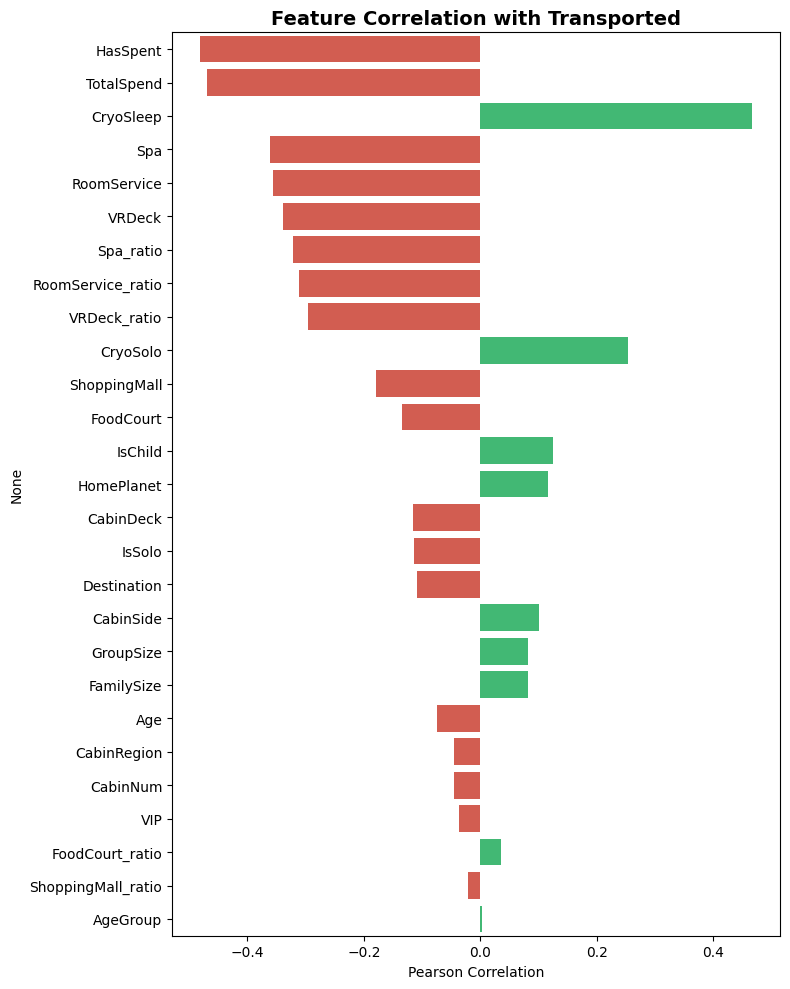

In [15]:
corr_with_target = X.assign(Transported=y).corr()['Transported'].drop('Transported').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 10))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target]
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)
plt.title('Feature Correlation with Transported', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_score(model, name):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'{name:30s}  {scores.mean():.4f} ± {scores.std():.4f}   {scores}')
    return scores.mean()

results = {}

In [17]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, C=0.5, random_state=SEED),
    'RandomForest':       RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    'HistGradBoost':      HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6, min_samples_leaf=20, random_state=SEED),
    'XGBoost':            XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=SEED, verbosity=0),
}

for name, model in models.items():
    results[name] = cv_score(model, name)

LogisticRegression              0.7924 ± 0.0066   [0.79873491 0.78320874 0.79240943 0.80034522 0.78711162]
RandomForest                    0.7993 ± 0.0056   [0.80391029 0.79125934 0.80621047 0.80034522 0.79459148]
HistGradBoost                   0.8085 ± 0.0013   [0.80966072 0.80736055 0.80851064 0.81012658 0.80667434]
XGBoost                         0.8105 ± 0.0074   [0.82058654 0.81483611 0.80391029 0.81300345 0.80034522]


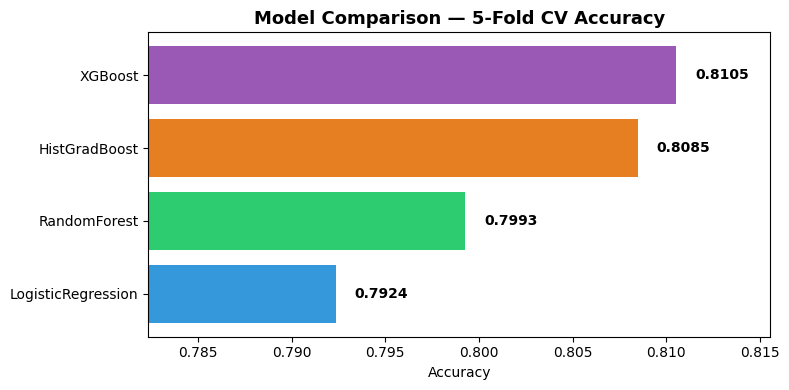

In [18]:
# Visual comparison
res_df = pd.Series(results).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
bars = plt.barh(res_df.index, res_df.values, color=['#3498db','#2ecc71','#e67e22','#9b59b6'][:len(res_df)])
plt.xlim(res_df.min() - 0.01, res_df.max() + 0.005)
for bar, val in zip(bars, res_df.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontweight='bold')
plt.title('Model Comparison — 5-Fold CV Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()

In [19]:
hgb_params = {
    'learning_rate':      [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_iter':           [200, 300, 500, 700],
    'max_depth':          [4, 5, 6, 8, None],
    'min_samples_leaf':   [10, 20, 30, 50],
    'l2_regularization':  [0.0, 0.01, 0.1, 1.0],
    'max_bins':           [128, 255],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=SEED),
    param_distributions=hgb_params,
    n_iter=40, cv=cv, scoring='accuracy',
    random_state=SEED, n_jobs=-1, verbose=1
)
hgb_search.fit(X, y)
print(f'\n🏆 Best HGB CV: {hgb_search.best_score_:.4f}')
print('   Params:', hgb_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

🏆 Best HGB CV: 0.8131
   Params: {'min_samples_leaf': 30, 'max_iter': 300, 'max_depth': 8, 'max_bins': 128, 'learning_rate': 0.03, 'l2_regularization': 0.0}


In [20]:
xgb_params = {
    'n_estimators':     [200, 300, 500, 700],
    'learning_rate':    [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_depth':        [4, 5, 6, 8],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha':        [0, 0.01, 0.1, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5, 10],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=SEED, verbosity=0),
    param_distributions=xgb_params,
    n_iter=40, cv=cv, scoring='accuracy',
    random_state=SEED, n_jobs=-1, verbose=1
)
xgb_search.fit(X, y)
print(f'\n🏆 Best XGB CV: {xgb_search.best_score_:.4f}')
print('   Params:', xgb_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

🏆 Best XGB CV: 0.8111
   Params: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [21]:
best_hgb = hgb_search.best_estimator_
best_xgb = xgb_search.best_estimator_
best_rf  = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=SEED, n_jobs=-1)

# --- Soft Voting ---
voting = VotingClassifier(
    estimators=[
        ('hgb', best_hgb),
        ('xgb', best_xgb),
        ('rf',  best_rf),
    ],
    voting='soft',
    n_jobs=-1
)
results['VotingEnsemble'] = cv_score(voting, 'Soft Voting Ensemble')

# --- Stacking ---
stacking = StackingClassifier(
    estimators=[
        ('hgb', best_hgb),
        ('xgb', best_xgb),
        ('rf',  best_rf),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=SEED),
    cv=cv,
    n_jobs=-1,
    passthrough=False
)
results['StackingEnsemble'] = cv_score(stacking, 'Stacking Ensemble')

Soft Voting Ensemble            0.8093 ± 0.0045   [0.8119609  0.80736055 0.80851064 0.81588032 0.80264672]
Stacking Ensemble               0.8103 ± 0.0030   [0.8119609  0.80736055 0.80908568 0.81530495 0.80782509]


In [22]:
# Final leaderboard
final = pd.Series(results).sort_values(ascending=False)
print('\n' + '='*55)
print('📊  FINAL MODEL LEADERBOARD (5-Fold CV Accuracy)')
print('='*55)
for i, (name, score) in enumerate(final.items(), 1):
    medal = ['🥇','🥈','🥉'][i-1] if i <= 3 else '  '
    print(f'  {medal} {name:30s}  {score:.4f}')
print('='*55)


📊  FINAL MODEL LEADERBOARD (5-Fold CV Accuracy)
  🥇 XGBoost                         0.8105
  🥈 StackingEnsemble                0.8103
  🥉 VotingEnsemble                  0.8093
     HistGradBoost                   0.8085
     RandomForest                    0.7993
     LogisticRegression              0.7924


In [23]:
# Automatically select the best model
best_name = final.index[0]
print(f'🏆 Using: {best_name} (CV = {final.iloc[0]:.4f})')

# Map name → model object
model_map = {
    'LogisticRegression': LogisticRegression(max_iter=2000, C=0.5, random_state=SEED),
    'RandomForest':       best_rf,
    'HistGradBoost':      best_hgb,
    'XGBoost':            best_xgb,
    'VotingEnsemble':     voting,
    'StackingEnsemble':   stacking,
}

final_model = model_map[best_name]
final_model.fit(X, y)
print('✅ Final model trained on ALL training data')

🏆 Using: XGBoost (CV = 0.8105)
✅ Final model trained on ALL training data


In [24]:
test_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_preds.astype(bool)
})

print(submission.head(10))
print(f'\nTransported distribution: {submission.Transported.value_counts(normalize=True).to_dict()}')

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01         True
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True

Transported distribution: {True: 0.5068973579611877, False: 0.49310264203881227}


In [25]:
submission.to_csv('../claude_submission.csv', index=False)
print('📁 Saved → claude_submission.csv')
print(f'   Rows: {len(submission)}')

📁 Saved → claude_submission.csv
   Rows: 4277


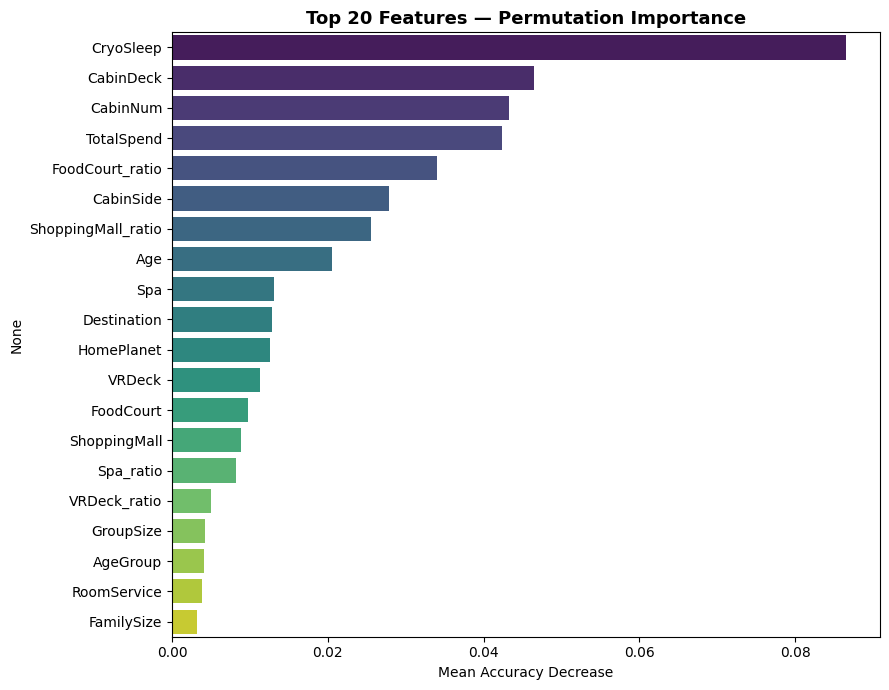

In [26]:
from sklearn.inspection import permutation_importance

# Use the tuned HGB for interpretability
best_hgb.fit(X, y)
r = permutation_importance(best_hgb, X, y, n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Top 20 Features — Permutation Importance', fontsize=13, fontweight='bold')
plt.xlabel('Mean Accuracy Decrease')
plt.tight_layout()
plt.show()